<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-02 22:50:09--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.5’

survey-results-publ 100%[===================>] 201.62M  34.9MB/s    in 5.5s    

2026-03-02 22:50:17 (36.8 MB/s) - ‘survey-results-public.sqlite.5’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [4]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [5]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [6]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


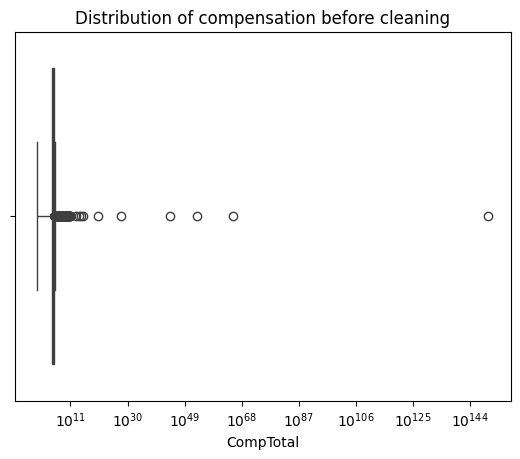

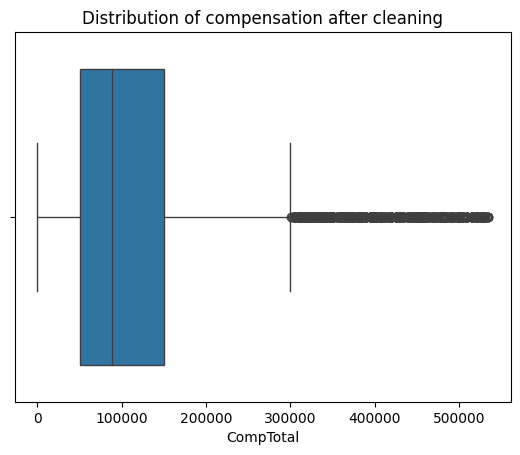

In [7]:
# your code goes here
CompTotal=pd.read_sql_query('Select CompTotal from main where CompTotal>0', conn)

Q1=np.quantile(CompTotal['CompTotal'], 0.25)
Q3=np.quantile(CompTotal['CompTotal'], 0.75)
IQR=Q3-Q1


cleanCompTotal=pd.read_sql_query(f'Select CompTotal from main where CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}', conn) # Extreme compensation values were removed using the IQR method to improve visualization clarity
                                                                                                                            # More about Compensation data in DataWrangling/09_ImputMissing_Values
sns.boxplot(x=CompTotal['CompTotal'])
plt.xscale('log')
plt.title('Distribution of compensation before cleaning')
plt.show()

sns.boxplot(x=cleanCompTotal['CompTotal'])
plt.title('Distribution of compensation after cleaning')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


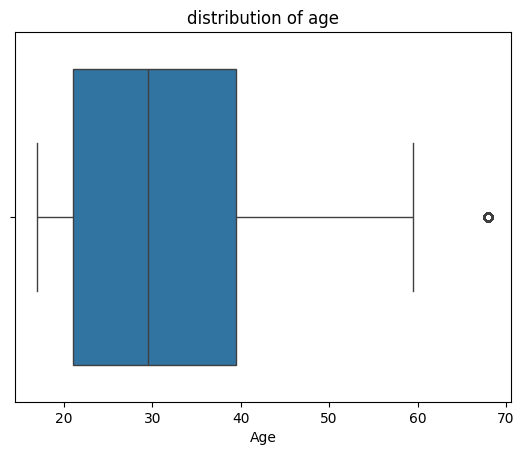

In [8]:
# your code goes here
age=pd.read_sql_query('Select Age from main where Age <> "Prefer not to say"', conn)  # Deleting this value to convert this column from object type to float

age['Age']=age['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age['Age']=pd.to_numeric(age['Age'],errors='coerce')
age = age.dropna(subset=['Age'])

sns.boxplot(x=age['Age'])
plt.xlabel('Age')
plt.title('distribution of age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


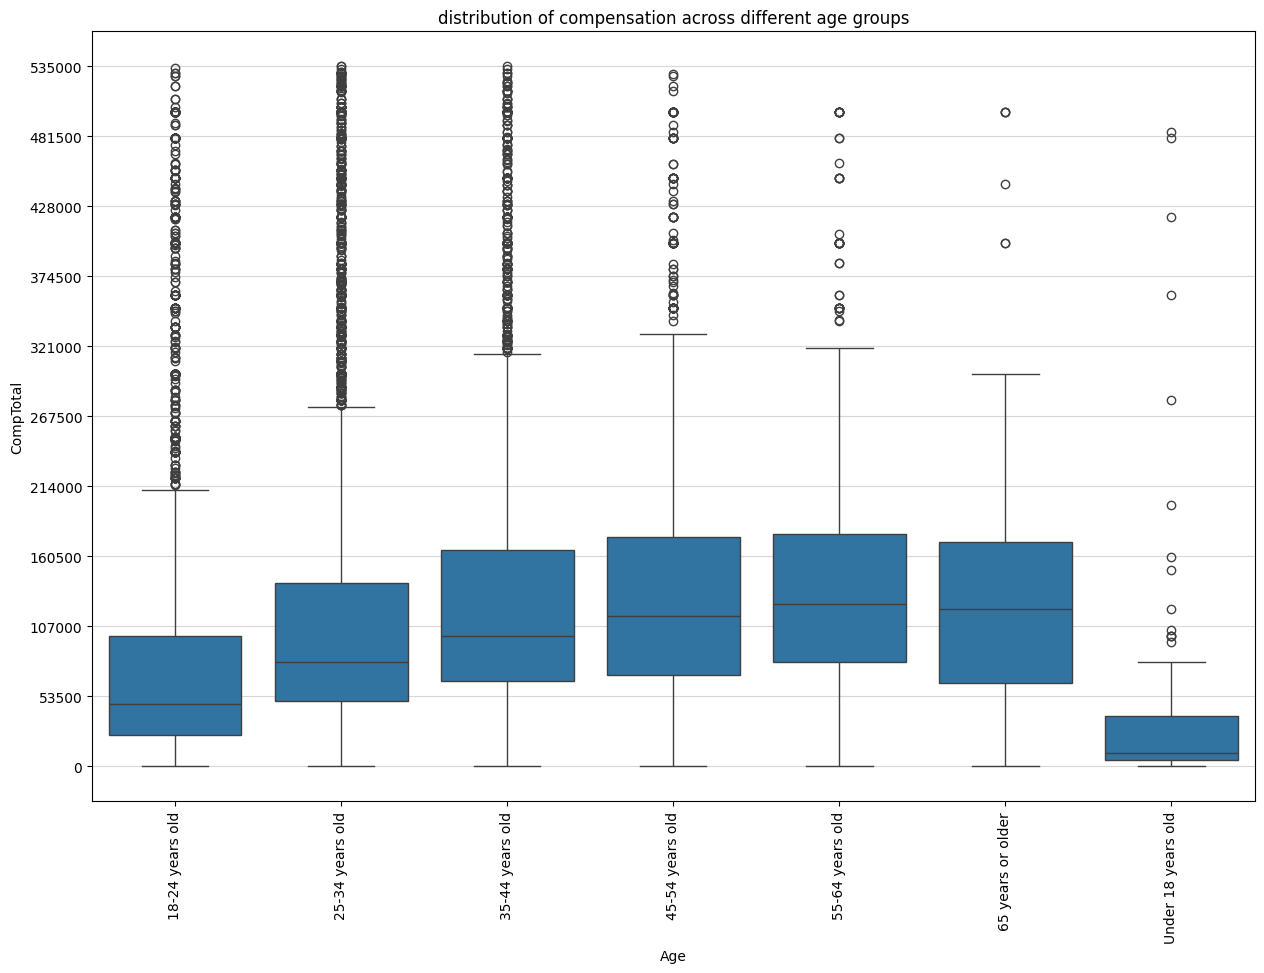

In [9]:
# your code goes here

age_comp=pd.read_sql_query(
    f'''Select Age, CompTotal 
    from main 
    where CompTotal is not null                                   
    and Age <> "Prefer not to say"
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn   # Extreme compensation values were removed using the IQR method to improve visualization clarity
)

age_comp=age_comp.sort_values('Age')

plt.figure(figsize=(15,10))
sns.boxplot(age_comp, x='Age', y='CompTotal')
plt.title('distribution of compensation across different age groups')
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=90)
plt.yticks(np.linspace(0,age_comp['CompTotal'].max(),11))
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [10]:
# your code goes here

sat_comp=pd.read_sql_query(
    f'''Select CompTotal, JobSatPoints_6 
    from main 
    where CompTotal is not null
    and JobSatPoints_6 is not null
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn  # Extreme compensation values were removed using the IQR method to improve visualization clarity
)

print('minimum value in JobSatPoints_6', sat_comp['JobSatPoints_6'].min(), '\t\tmaximum value in JobSatPoints_6', sat_comp['JobSatPoints_6'].max())

minimum value in JobSatPoints_6 0.0 		maximum value in JobSatPoints_6 100.0


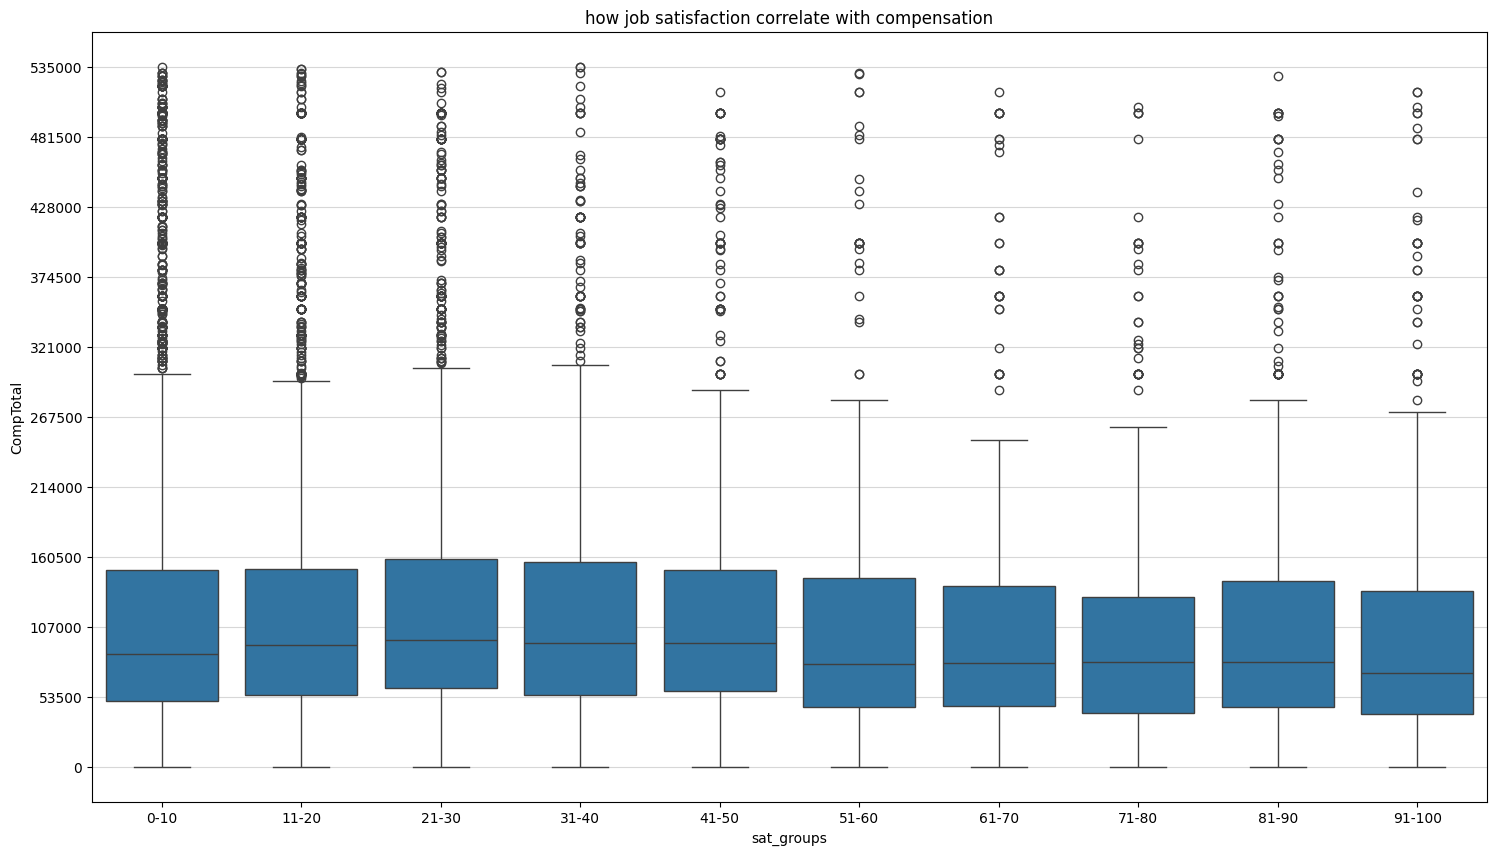

In [11]:
groups=np.linspace(0, 100, 11)
group_names=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
sat_comp['sat_groups']=pd.cut(sat_comp['JobSatPoints_6'], bins=groups, right=True, labels=group_names, include_lowest=True)

plt.figure(figsize=(18,10))
sns.boxplot(sat_comp, x='sat_groups', y='CompTotal')
plt.title('how job satisfaction correlate with compensation')
plt.grid(axis='y', alpha=0.5)
plt.yticks(np.linspace(0,sat_comp['CompTotal'].max(),11))
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [12]:
# your code goes here
Query=(
    '''with devtype_counts as (
    select 
        DevType,
        Count(DevType) AS DevTypeCount
    from main
    where 
        ConvertedCompYearly is not null
        and DevType is not null
    group by DevType
    order by DevTypeCount desc
    limit 5
)

select 
    m.DevType,
    m.ConvertedCompYearly
from main m
join devtype_counts d
    on m.DevType = d.DevType
where 
    m.ConvertedCompYearly is not null'''
)

Dev_comp=pd.read_sql_query(Query, conn)

In [13]:
Q1C=np.quantile(Dev_comp['ConvertedCompYearly'], 0.25)
Q3C=np.quantile(Dev_comp['ConvertedCompYearly'], 0.75)
IQRC=Q3C-Q1C

max_value=Q3C+1.5*IQRC
min_value=Q1C-1.5*IQRC

Dev_comp=Dev_comp[
                    (Dev_comp['ConvertedCompYearly']>min_value)  # Extreme compensation values were removed using the IQR method to improve visualization clarity
                    & (Dev_comp['ConvertedCompYearly']<max_value)
]

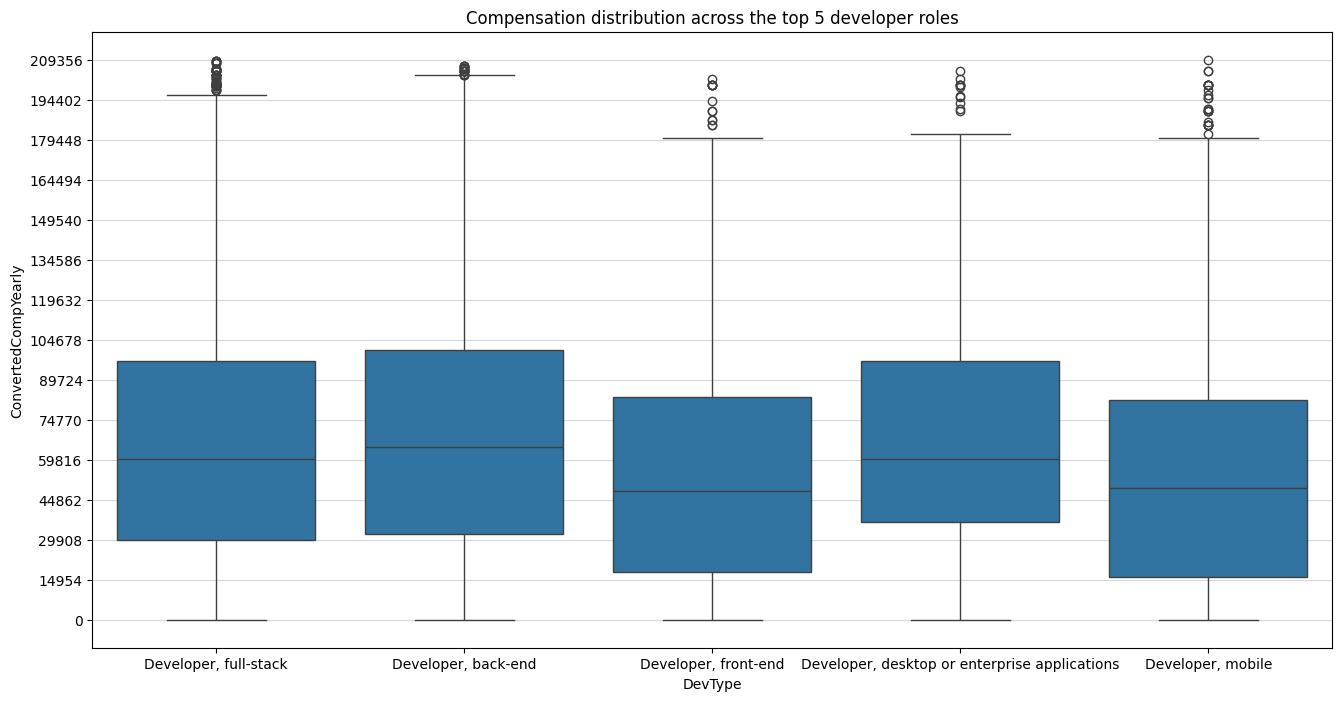

In [14]:
plt.figure(figsize=(16,8))
sns.boxplot(Dev_comp, x='DevType', y='ConvertedCompYearly')
plt.title('Compensation distribution across the top 5 developer roles')
plt.yticks(np.linspace(0, Dev_comp['ConvertedCompYearly'].max(),15))
plt.grid(axis='y', alpha=0.5)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [15]:
# your code goes here

Query2=(f'''
with country_counts as (
    select 
        Country,
        Count(Country) AS CountryCount
    from main
    where 
        CompTotal is not null
        and Country is not null
    group by Country
    order by CountryCount desc
    limit 5
)

select 
    m.Country,
    m.CompTotal
from main m
join country_counts c
    on m.Country = c.Country
where 
    m.CompTotal is not null
    and m.CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}'''     # Extreme compensation values were removed using the IQR method to improve visualization clarity
)

country_comp=pd.read_sql_query(Query2, conn)

country_comp['Country']=country_comp['Country'].replace('United Kingdom of Great Britain and Northern Ireland','UK')

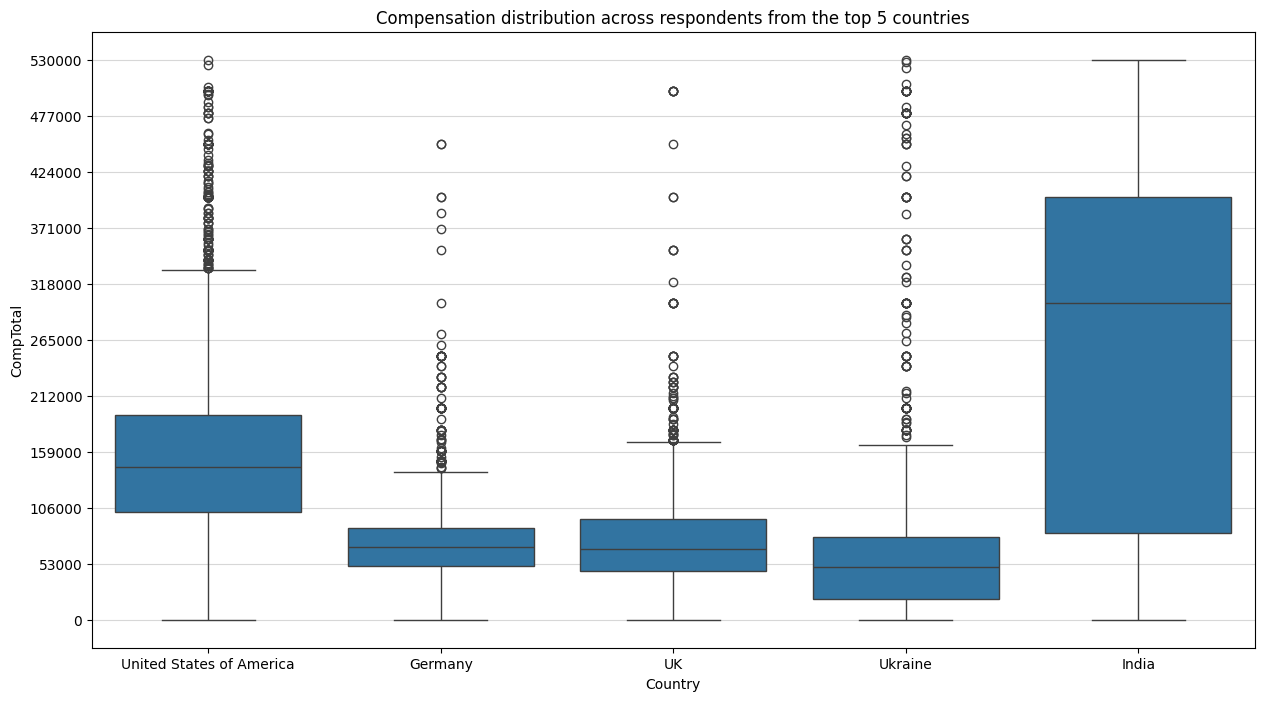

In [16]:
plt.figure(figsize=(15,8))
sns.boxplot(country_comp, x='Country', y='CompTotal')
plt.title('Compensation distribution across respondents from the top 5 countries')
plt.yticks(np.linspace(0,country_comp['CompTotal'].max(),11))
plt.grid(axis='y', alpha=0.5)
plt.show()

**Note that the CompTotal column is not currency-normalized. The apparent dominance of certain regions, like India, is due to salaries being reported in local currency rather than a standardized unit like USD**

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [17]:
# your code goes here

emp_comp=pd.read_sql_query(
    f'''Select Employment, CompTotal
    from main
    where CompTotal is not null
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn   # Extreme compensation values were removed using the IQR method to improve visualization clarity
)

emp_comp['new_employment']=emp_comp['Employment'].str.split(';')
emp_comp=emp_comp.explode('new_employment')

top10=(emp_comp.groupby('new_employment').size()
       .sort_values(ascending=False).head(10).index
      )
emp_comp=emp_comp[emp_comp['new_employment'].isin(top10)]

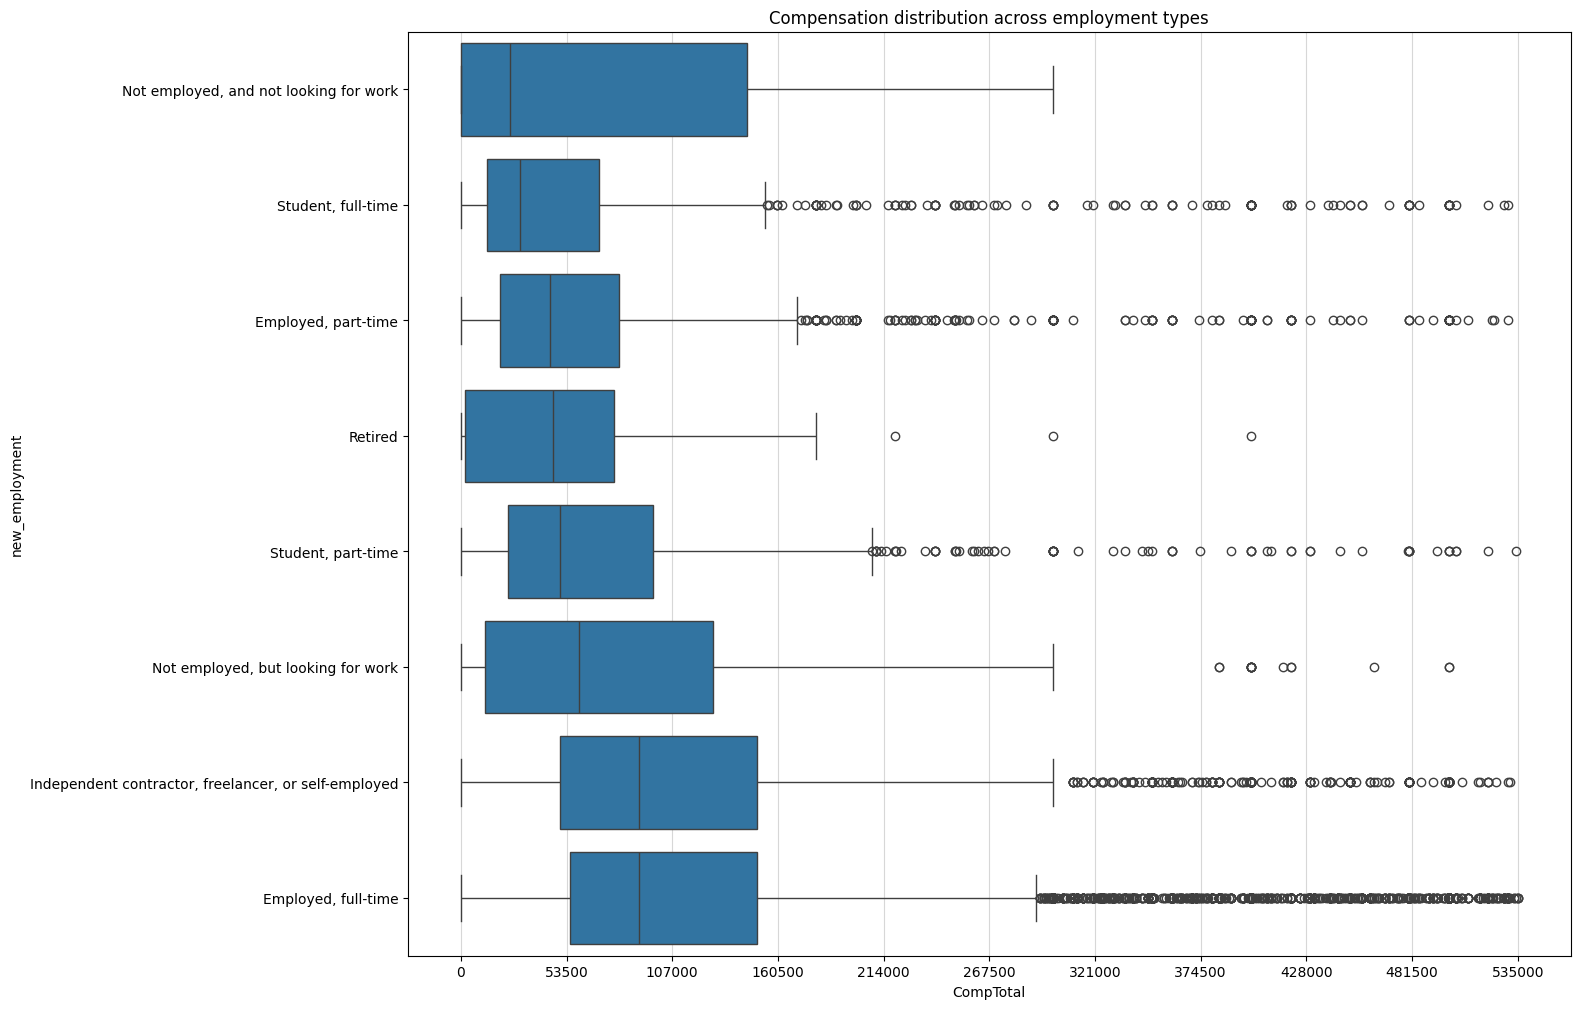

In [18]:
plt.figure(figsize=(15,12))
sns.boxplot(
    data=emp_comp
    ,x='CompTotal', y='new_employment'
    ,order = (emp_comp.groupby('new_employment')['CompTotal'].median().sort_values().index)
)
plt.title('Compensation distribution across employment types')
plt.xticks(np.linspace(0,emp_comp['CompTotal'].max(),11))
plt.grid(axis='x', alpha=0.5)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [19]:
# your code goes here

years_sat=pd.read_sql_query(
    '''select YearsCodePro, JobSatPoints_6
    from main 
    where YearsCodePro is not null
    and JobSatPoints_6 is not null''', conn
)

years_sat['YearsCodePro']=years_sat['YearsCodePro'].replace({                         # Convert categorical edge values into approximate numeric representations
                                                            'Less than 1 year': 0.5
                                                            ,'More than 50 years': 54
})

years_sat['YearsCodePro']=pd.to_numeric(years_sat['YearsCodePro'], errors='coerce')
years_sat=years_sat.dropna()

print('minimum value in JobSatPoints_6', years_sat['JobSatPoints_6'].min(), '\t\tmaximum value in JobSatPoints_6', years_sat['JobSatPoints_6'].max())

minimum value in JobSatPoints_6 0.0 		maximum value in JobSatPoints_6 100.0


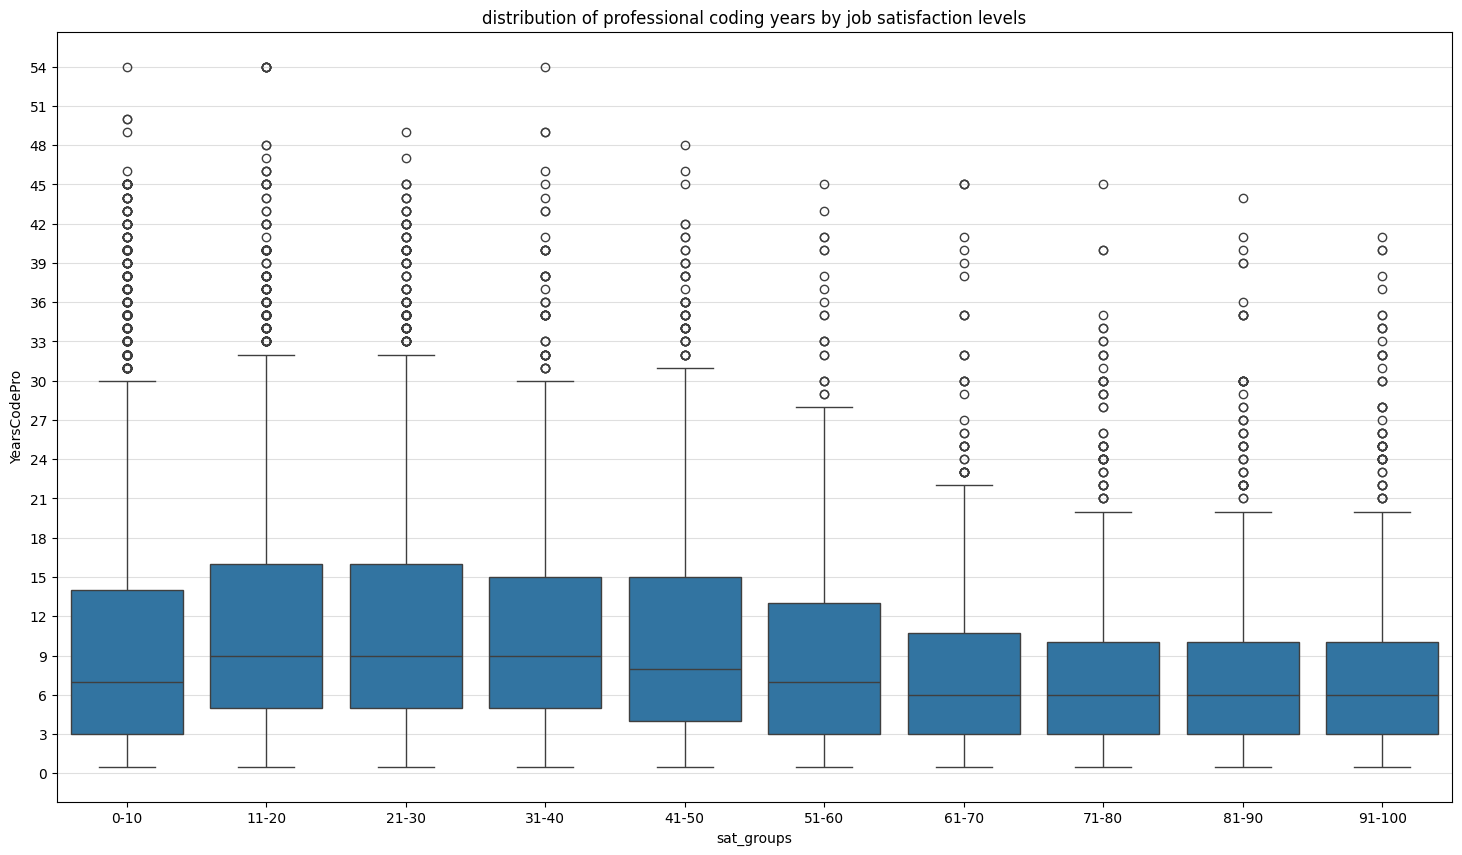

In [20]:
groups2=np.linspace(0, 100, 11)
group_names2=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
years_sat['sat_groups']=pd.cut(years_sat['JobSatPoints_6'], bins=groups2, right=True, labels=group_names2, include_lowest=True)

plt.figure(figsize=(18,10))
sns.boxplot(years_sat, x='sat_groups', y='YearsCodePro')
plt.title('distribution of professional coding years by job satisfaction levels')
plt.grid(axis='y', alpha=0.4)
plt.yticks(np.linspace(0,years_sat['YearsCodePro'].max(),19))
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [21]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
